In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn import metrics
from sklearn import preprocessing
import pickle

In [2]:
scaler = preprocessing.MinMaxScaler()

In [3]:
data=pd.read_csv('out time separated.csv')
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Shape,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
0,0,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,18
1,1,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11
2,2,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11
3,3,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,13
4,4,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11


In [4]:
data=data.sample(frac=1)
#data= data[data['Detector_Size'] == 10]
#data.drop(['Unnamed: 0','Shape','Detector_Size','Cover_Size','CH4','CO2'],axis=1,inplace=True)
#data= data.set_index('Event')


#data= data[data['Gas_Type'] != 'p10']
data.drop(['Shape'],axis=1,inplace=True)


data = data[data['Time_Window'].isin([10, 15, 25])]
#data.drop(['Time_Window'],axis=1,inplace=True)



#data= data[(data['Voltage'] >= 4500) & (data['Voltage'] <= 5500)]
#data= data[data['Detector_Size'] == 10]

#data.drop(['Voltage'],axis=1,inplace=True)


In [5]:
#groupByData = data.groupby(['Gas_Type', 'Detector_Size','Cover_Size','Voltage','Time_Window','Source'])

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7370 entries, 58258 to 56388
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7370 non-null   int64  
 1   Gas_Type          7370 non-null   object 
 2   CH4               7370 non-null   float64
 3   Ar                7370 non-null   float64
 4   N2                7370 non-null   float64
 5   CO2               7370 non-null   float64
 6   C                 7370 non-null   float64
 7   O                 7370 non-null   float64
 8   H                 7370 non-null   float64
 9   Detector_Size     7370 non-null   float64
 10  Detector_Area     7370 non-null   float64
 11  Cover_Size        7370 non-null   float64
 12  Cover_Area        7370 non-null   float64
 13  Cover_Area_Ratio  7370 non-null   float64
 14  Voltage           7370 non-null   int64  
 15  Source            7370 non-null   object 
 16  Time_Window       7370 non-null   int64  


In [7]:
data.isnull()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
58258,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
35843,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
55208,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
38438,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
24996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22169,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2355,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
21454,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
60872,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
data.isnull().sum()

Unnamed: 0          0
Gas_Type            0
CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

<Axes: >

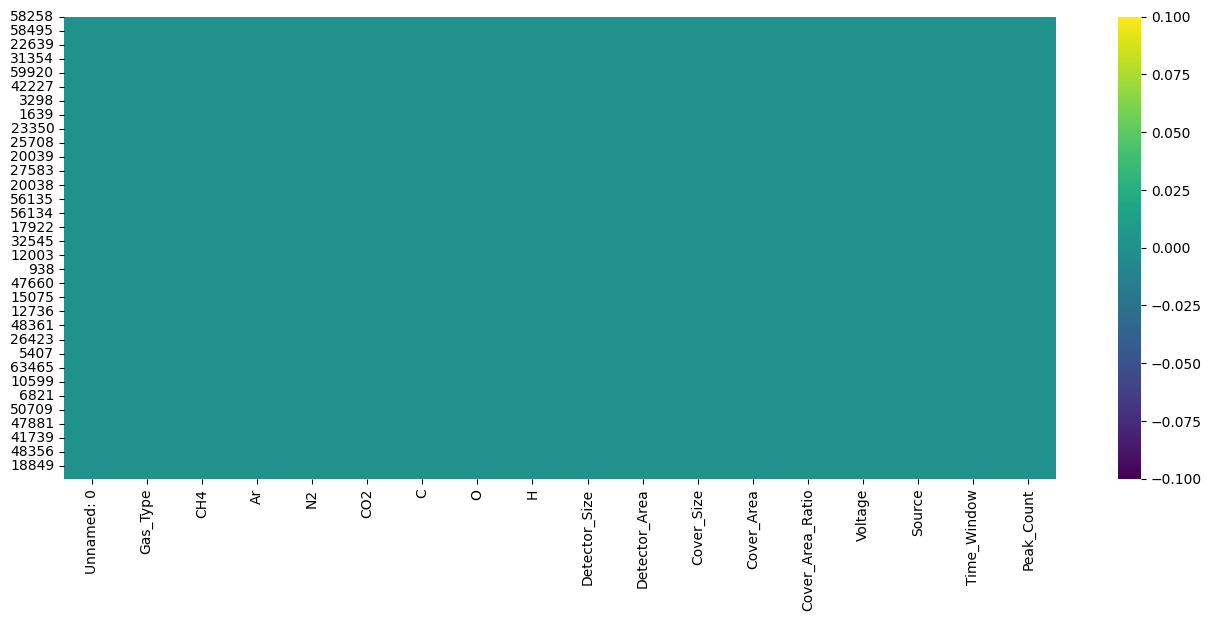

In [9]:
plt.figure(figsize=(16, 6))
sns.heatmap(data.isnull(),cmap='viridis')

In [10]:
data.dropna(inplace=True)

In [11]:
data.isnull().sum()

Unnamed: 0          0
Gas_Type            0
CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

In [12]:
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
58258,58258,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,3000,kaynaksız,10,2766
35843,35843,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,5500,kaynaksız,10,134
55208,55208,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,3500,cs,15,0
38438,38438,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,3000,cs,10,0
24996,24996,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,6.00,36.00,0.36,7000,kaynaksız,15,325


In [13]:
type2=pd.get_dummies(data['Gas_Type'],dtype=float)
type2

,arnco2,p10,p20
58258,1.0,0.0,0.0
35843,0.0,0.0,1.0
55208,1.0,0.0,0.0
38438,0.0,0.0,1.0
24996,0.0,0.0,1.0
...,...,...,...
22169,0.0,1.0,0.0
2355,0.0,1.0,0.0
21454,0.0,1.0,0.0
60872,1.0,0.0,0.0


In [14]:
type=pd.get_dummies(data['Source'],dtype=float)
type

,cs,kaynaksız
58258,0.0,1.0
35843,0.0,1.0
55208,1.0,0.0
38438,1.0,0.0
24996,0.0,1.0
...,...,...
22169,0.0,1.0
2355,0.0,1.0
21454,0.0,1.0
60872,1.0,0.0


In [15]:
data['KV2'] = (data['Voltage']/1000)**2
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count,KV2
58258,58258,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,3000,kaynaksız,10,2766,9.00
35843,35843,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,5500,kaynaksız,10,134,30.25
55208,55208,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,3500,cs,15,0,12.25
38438,38438,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,3000,cs,10,0,9.00
24996,24996,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,6.00,36.00,0.36,7000,kaynaksız,15,325,49.00


In [16]:
data=pd.concat([data,type2,type],axis=1)
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,...,Voltage,Source,Time_Window,Peak_Count,KV2,arnco2,p10,p20,cs,kaynaksız
58258,58258,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,...,3000,kaynaksız,10,2766,9.00,1.0,0.0,0.0,0.0,1.0
35843,35843,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,...,5500,kaynaksız,10,134,30.25,0.0,0.0,1.0,0.0,1.0
55208,55208,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,...,3500,cs,15,0,12.25,1.0,0.0,0.0,1.0,0.0
38438,38438,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,...,3000,cs,10,0,9.00,0.0,0.0,1.0,1.0,0.0
24996,24996,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,...,7000,kaynaksız,15,325,49.00,0.0,0.0,1.0,0.0,1.0


In [17]:
#sns.set(style="ticks", color_codes=True)
#g = sns.pairplot(data)
#plt.show()

In [18]:
data.drop(['Source','kaynaksız','Gas_Type','Unnamed: 0'],axis=1,inplace=True)
#data.drop(['CH4','Ar','N2','CO2','C','O','H'],axis=1,inplace=True)
data.drop(['p10','p20','arnco2'],axis=1,inplace=True)


data.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,KV2,cs
58258,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,3000,10,2766,9.00,0.0
35843,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,5500,10,134,30.25,0.0
55208,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,3500,15,0,12.25,1.0
38438,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,3000,10,0,9.00,1.0
24996,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,6.00,36.00,0.36,7000,15,325,49.00,0.0


In [19]:
names = data.columns

In [20]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7370 entries, 58258 to 56388
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CH4               7370 non-null   float64
 1   Ar                7370 non-null   float64
 2   N2                7370 non-null   float64
 3   CO2               7370 non-null   float64
 4   C                 7370 non-null   float64
 5   O                 7370 non-null   float64
 6   H                 7370 non-null   float64
 7   Detector_Size     7370 non-null   float64
 8   Detector_Area     7370 non-null   float64
 9   Cover_Size        7370 non-null   float64
 10  Cover_Area        7370 non-null   float64
 11  Cover_Area_Ratio  7370 non-null   float64
 12  Voltage           7370 non-null   int64  
 13  Time_Window       7370 non-null   int64  
 14  Peak_Count        7370 non-null   int64  
 15  KV2               7370 non-null   float64
 16  cs                7370 non-null   float64


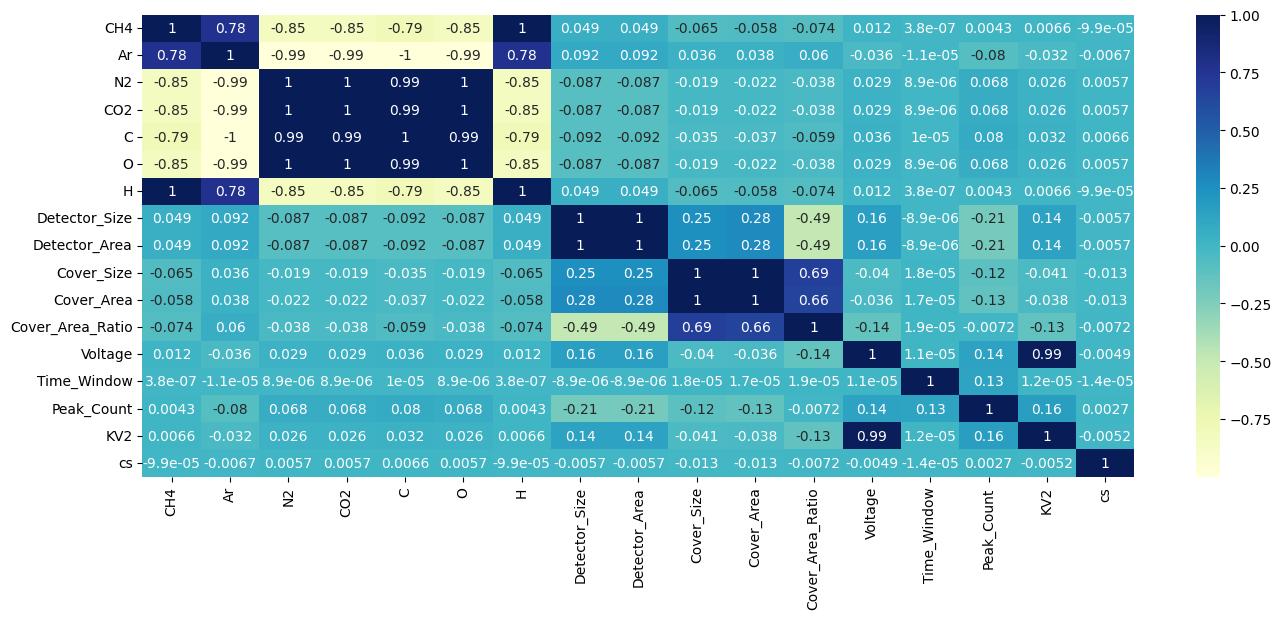

In [21]:
# creation of correlation matrix
corrM = data.corr()
plt.figure(figsize=(16, 6))
dataplot = sns.heatmap(corrM, cmap="YlGnBu", annot=True) 


In [22]:
corr = corrM[abs(corrM['Peak_Count'])>0.1][['Peak_Count']]
list(corr.index)

['Detector_Size',
 'Detector_Area',
 'Cover_Size',
 'Cover_Area',
 'Voltage',
 'Time_Window',
 'Peak_Count',
 'KV2']

In [23]:
#data=data[list(corr.index)]
data

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,KV2,cs
58258,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,3000,10,2766,9.00,0.0
35843,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,5500,10,134,30.25,0.0
55208,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,3500,15,0,12.25,1.0
38438,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,3000,10,0,9.00,1.0
24996,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,6.00,36.00,0.36,7000,15,325,49.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22169,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,3000,15,0,9.00,0.0
2355,0.1,0.90,0.00,0.0,0.02,0.0,0.08,10.00,100.00,6.00,36.00,0.36,4500,25,174,20.25,0.0
21454,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,2000,10,0,4.00,0.0
60872,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,2000,15,1310,4.00,1.0


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
x=data.drop(['Peak_Count'],axis=1)

x.head()

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,cs
58258,0.0,0.05,0.35,0.6,0.20,0.4,0.00,6.78,45.97,4.78,22.85,0.50,3000,10,9.00,0.0
35843,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,5500,10,30.25,0.0
55208,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,8.00,64.00,0.64,3500,15,12.25,1.0
38438,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,3000,10,9.00,1.0
24996,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,6.00,36.00,0.36,7000,15,49.00,0.0


In [26]:
y=data['Peak_Count']
y

58258    2766
35843     134
55208       0
38438       0
24996     325
         ... 
22169       0
2355      174
21454       0
60872    1310
56388      16
Name: Peak_Count, Length: 7370, dtype: int64

In [27]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [28]:
scalerModel = scaler.fit(x)
X_train = scalerModel.transform(X_train)
X_test = scalerModel.transform(X_test)

In [29]:
from sklearn.linear_model import LinearRegression

In [30]:
model=LinearRegression()

In [31]:
model.fit(X_train,y_train)

LinearRegression()

In [32]:
pred=model.predict(X_test)
pred

array([637.625, 101.125, 130.875, ..., -56.625,  72.125, 431.625])

In [33]:
y_test

926        694
46233        0
3764        22
14605       70
28544    16810
         ...  
33266      126
52371        7
57568        0
46478        0
30908      205
Name: Peak_Count, Length: 1474, dtype: int64

In [34]:
X_test

array([[0.5       , 1.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.        , 0.53333333,
        1.        ],
       [0.5       , 1.        , 0.        , ..., 0.33333333, 0.1375    ,
        0.        ],
       ...,
       [0.        , 0.        , 1.        , ..., 0.33333333, 0.1375    ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.33333333, 0.2       ,
        1.        ],
       [1.        , 0.88235294, 0.        , ..., 1.        , 0.75      ,
        0.        ]])

In [35]:
model.score(X_test, y_test)

0.14232184834508177

In [36]:
pred

array([637.625, 101.125, 130.875, ..., -56.625,  72.125, 431.625])

In [37]:
y_test

926        694
46233        0
3764        22
14605       70
28544    16810
         ...  
33266      126
52371        7
57568        0
46478        0
30908      205
Name: Peak_Count, Length: 1474, dtype: int64

In [38]:
#indexes = X_test.index.values
#index=indexes[98]

In [39]:
#X_test.loc[index]

In [40]:
#y_test[index],pred[98]
pred[pred<=0] = 0

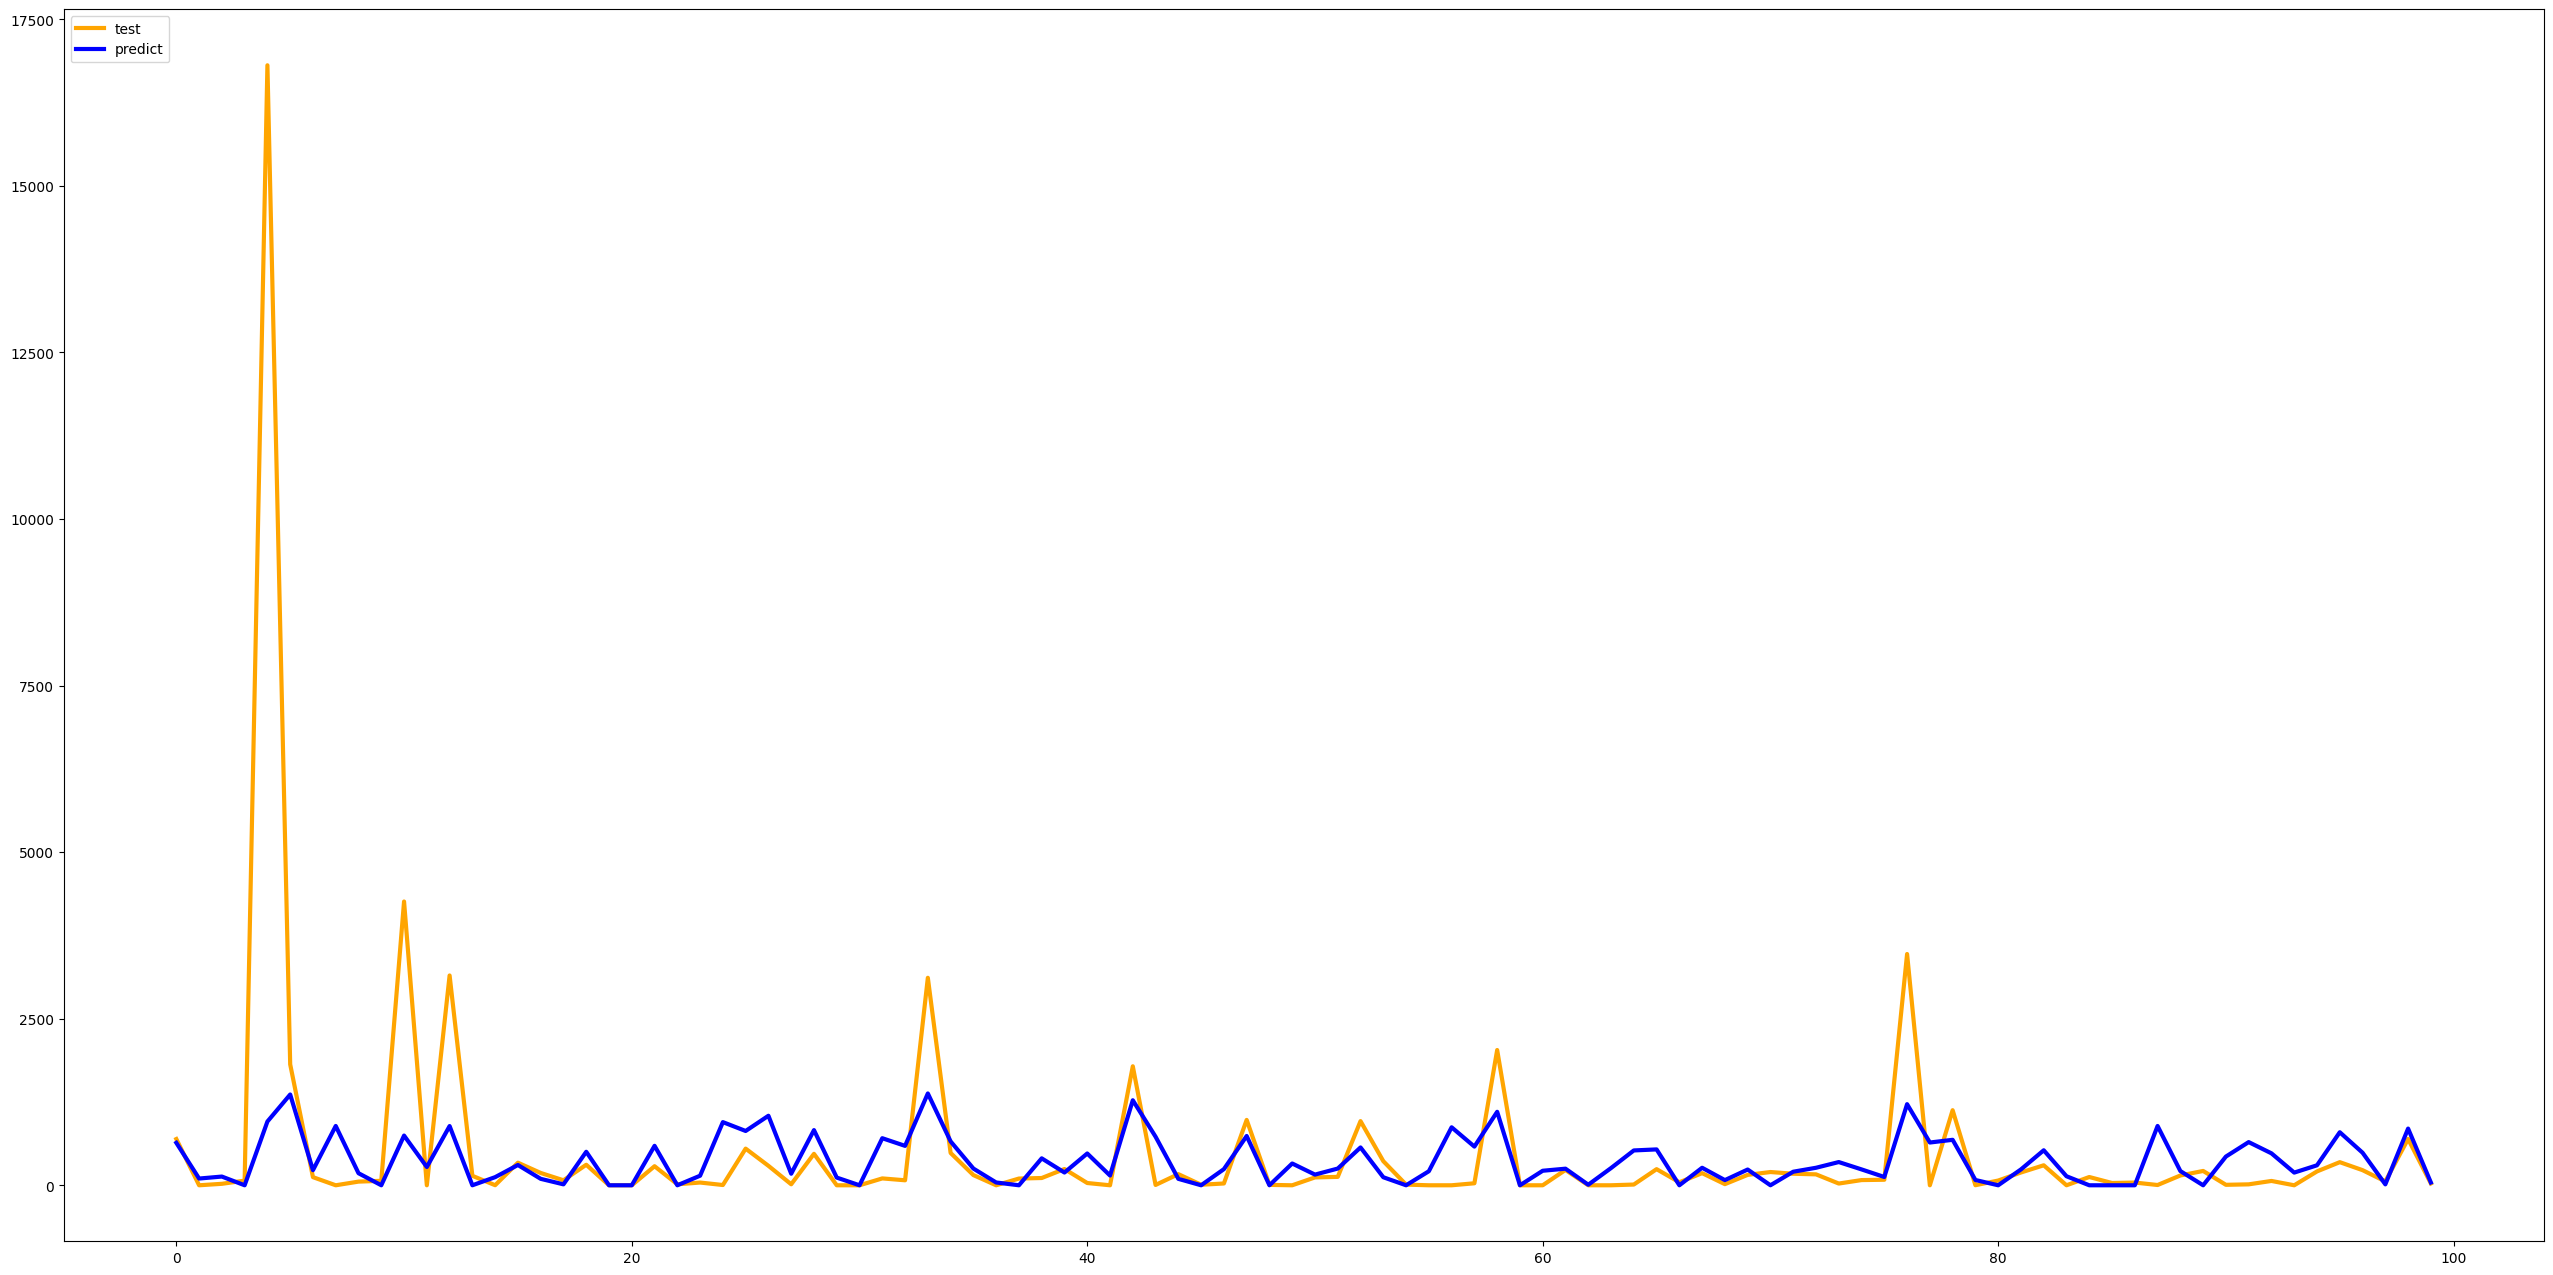

In [41]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(X_test))[:100],y_test[:100], color="orange", linewidth=3 ,label = 'test')
plt.plot(range(0,len(X_test))[:100],pred[:100], color="blue", linewidth=3,label = 'predict')
plt.legend(loc="upper left")
plt.show()

In [43]:
#indexes = X_test.index.values
#index=indexes[98]

In [44]:
#X_test.loc[index]

In [45]:
#y_test[index],pred[98]

In [46]:
#metrics.mean_absolute_error(y_true, y_pred, *) -> Mean absolute error regression loss.
metrics.mean_absolute_error(y_test, pred)

336.45607191316145

In [47]:
#metrics.mean_squared_error(y_true, y_pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred)

939058.9478459973

In [48]:
#metrics.mean_squared_error(y_true, pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred)**0.5

969.0505393662382

In [49]:
#metrics.mean_absolute_percentage_error(...) -> Mean absolute percentage error (MAPE) regression loss.
metrics.mean_absolute_percentage_error(y_test, pred)

1.7090343277254803e+17

In [50]:
#metrics.r2_score(y_true, y_pred, *[, ...]) -> (coefficient of determination) regression score function.
metrics.r2_score(y_test, pred)

0.14660639037647438

In [51]:
metrics.explained_variance_score(y_test, pred)

0.1466726481775995

In [52]:
from pyGRNN import GRNN

In [53]:
model_grnn = GRNN(sigma=5)

In [54]:
#dbfile = open('grnn_model.pickle', 'ab')
#pickle.dump(model_grnn, dbfile)                    
#dbfile.close()

In [55]:
#with (open("grnn_model.pickle", "rb")) as openfile:
    #model_grnn=pickle.load(openfile)

model_grnn.fit(X_train,y_train)

Executing warm start...
Warm start concluded. The optimum isotropic sigma is [0.03061109]
Gradient search concluded. The optimum sigma is [ 0.031       0.031       0.031       0.031       0.031       0.031
  0.031       0.031       0.031       0.031       0.031       0.031
  0.02776288  0.031      10.36966193  0.031     ]


GRNN(bnds=((0, None), (0, None), (0, None), (0, None), (0, None), (0, None),
           (0, None), (0, None), (0, None), (0, None), (0, None), (0, None),
           (0, None), (0, None), (0, None), (0, None)),
     sigma=array([ 0.031     ,  0.031     ,  0.031     ,  0.031     ,  0.031     ,
        0.031     ,  0.031     ,  0.031     ,  0.031     ,  0.031     ,
        0.031     ,  0.031     ,  0.02776288,  0.031     , 10.36966193,
        0.031     ]))

In [56]:
pred_grnn=model_grnn.predict(X_test)
pred_grnn

array([3.84232541e+02, 2.10133941e-01, 2.95320963e+01, ...,
       1.44402363e-01, 1.63099889e-01, 1.83791497e+02])

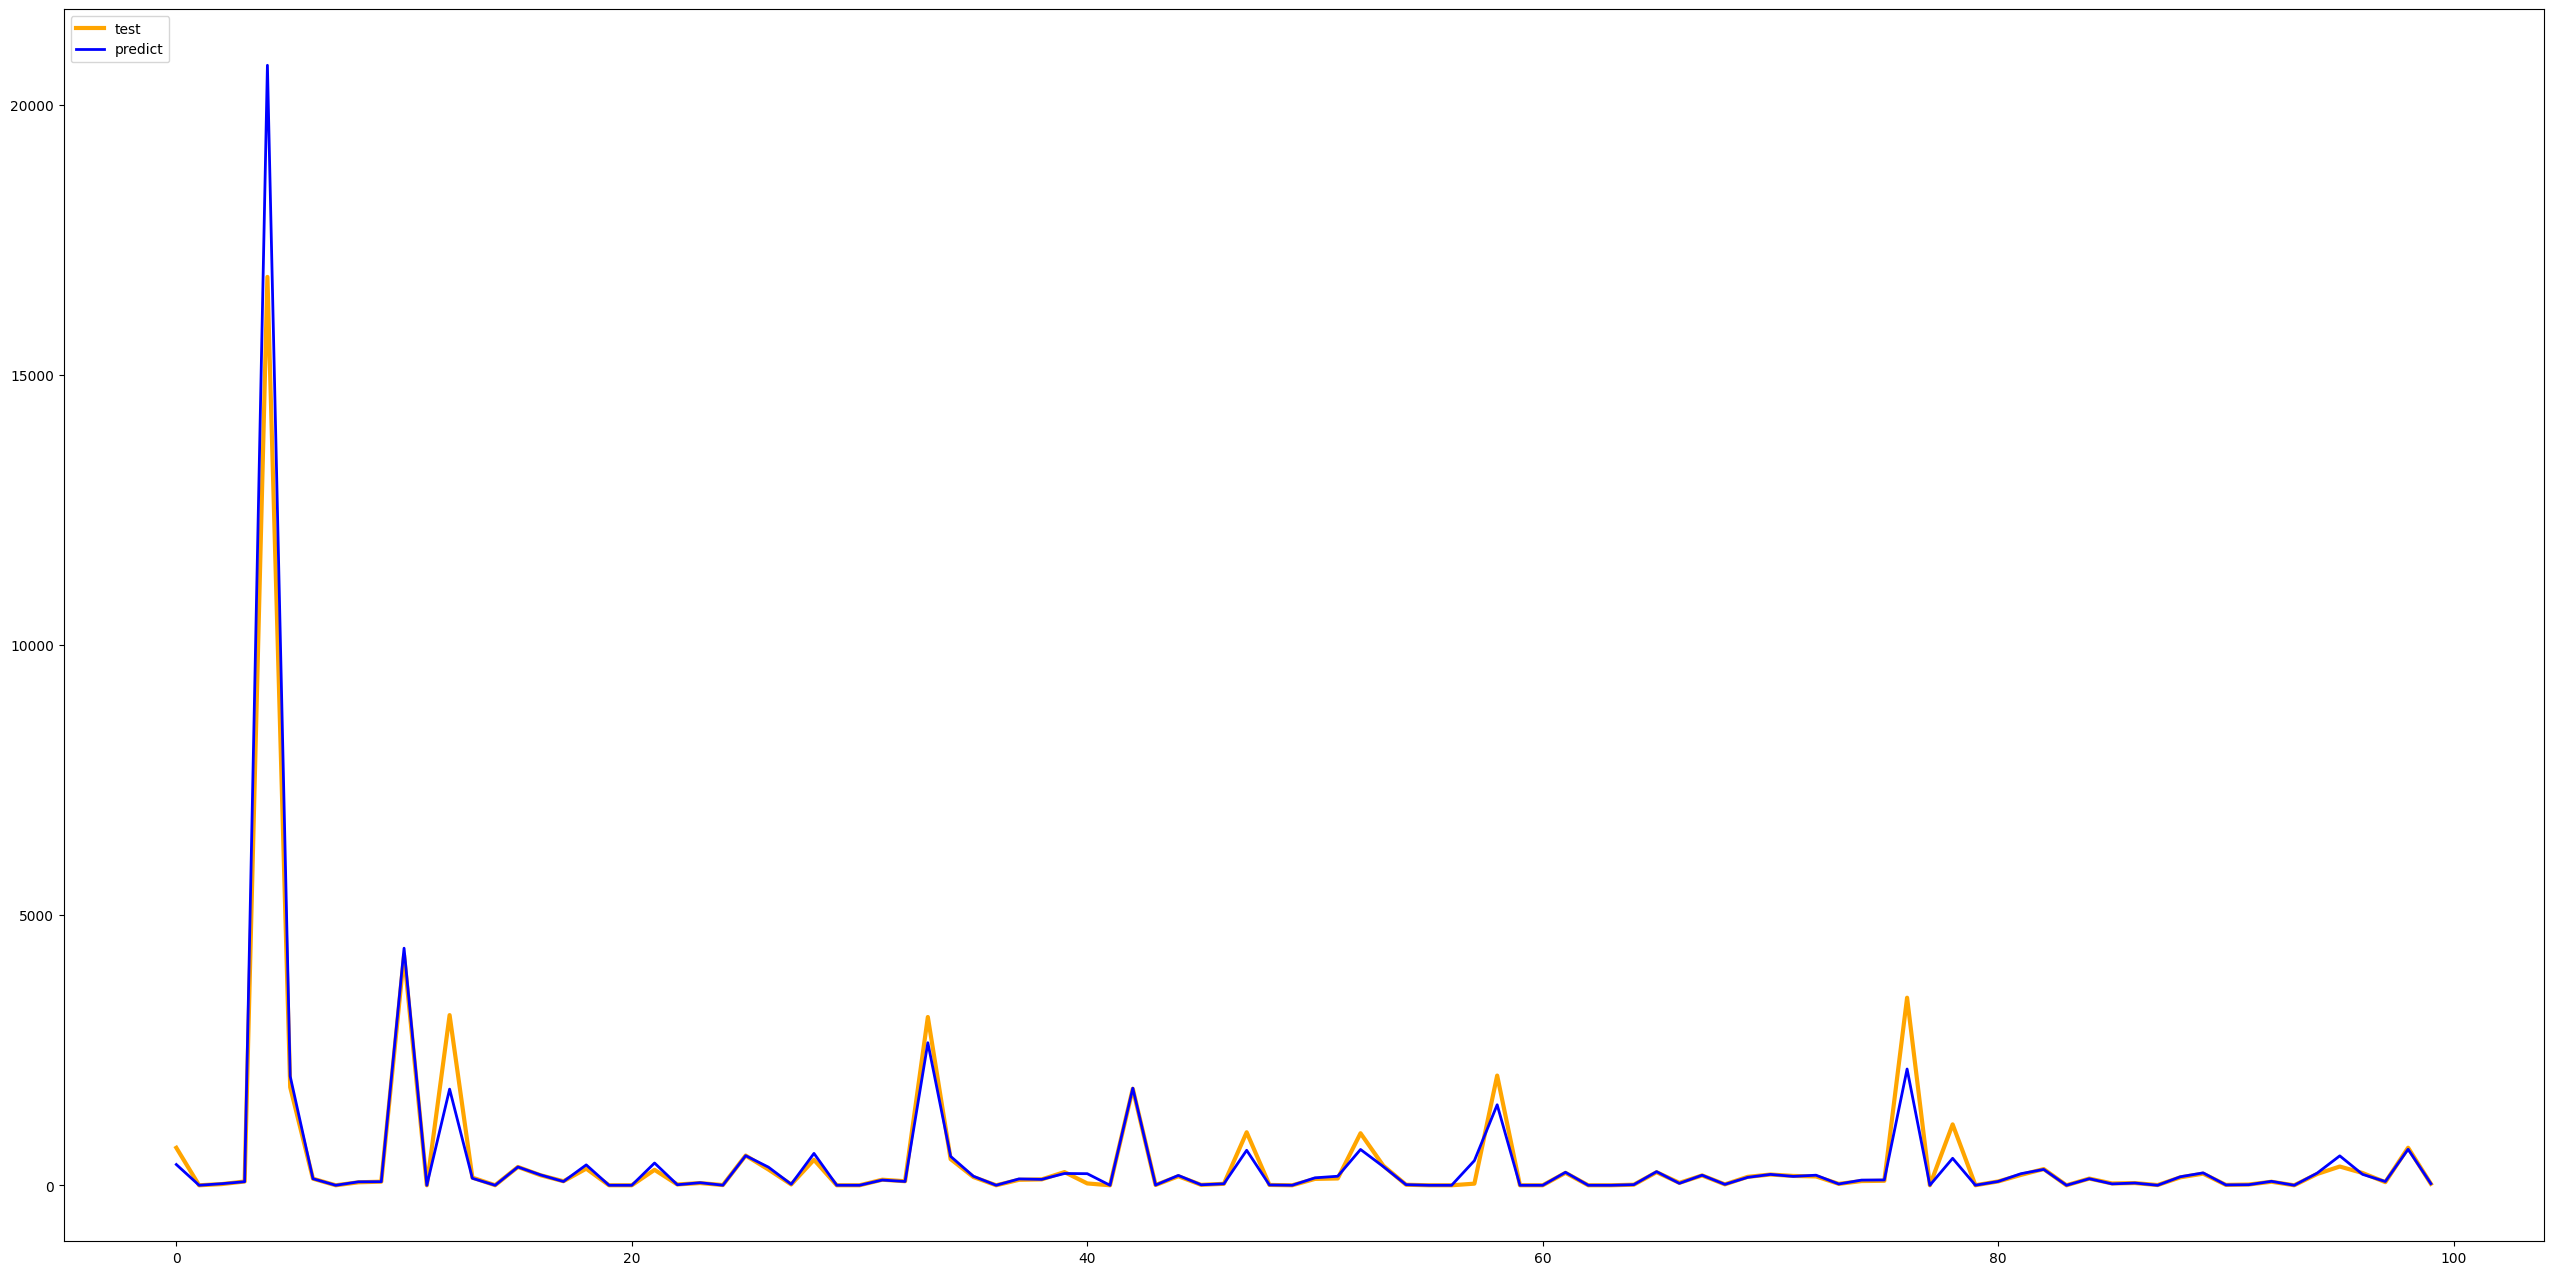

In [57]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(X_test))[:100],y_test[:100], color="orange", linewidth=3 ,label = 'test')
plt.plot(range(0,len(X_test))[:100],pred_grnn[:100], color="blue", linewidth=2,label = 'predict')
plt.legend(loc="upper left")
plt.show()

In [58]:
X_test['olcum'] = y_test
X_test['tahmin'] = pred_grnn
X_test

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [59]:
#metrics.mean_absolute_error(y_true, y_pred, *) -> Mean absolute error regression loss.
metrics.mean_absolute_error(y_test, pred_grnn)

77.28179670992034

In [60]:
#metrics.mean_squared_error(y_true, y_pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred_grnn)

111223.7983833566

In [61]:
#metrics.mean_squared_error(y_true, pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred_grnn)**0.5

333.50232140624837

In [62]:
#metrics.mean_absolute_percentage_error(...) -> Mean absolute percentage error (MAPE) regression loss.
metrics.mean_absolute_percentage_error(y_test, pred_grnn)

178138537419528.88

In [63]:
#metrics.r2_score(y_true, y_pred, *[, ...]) -> (coefficient of determination) regression score function.
metrics.r2_score(y_test, pred_grnn)

0.8989225553985369

In [64]:
metrics.explained_variance_score(y_test, pred_grnn)

0.8991541693853383

In [65]:
row = data.loc[data.index.values[0]]
row

CH4                    0.00
Ar                     0.05
N2                     0.35
CO2                    0.60
C                      0.20
O                      0.40
H                      0.00
Detector_Size          6.78
Detector_Area         45.97
Cover_Size             4.78
Cover_Area            22.85
Cover_Area_Ratio       0.50
Voltage             3000.00
Time_Window           10.00
Peak_Count          2766.00
KV2                    9.00
cs                     0.00
Name: 58258, dtype: float64

In [66]:
row = dict(row)
row

{'CH4': 0.0,
 'Ar': 0.05,
 'N2': 0.35,
 'CO2': 0.6,
 'C': 0.2,
 'O': 0.4,
 'H': 0.0,
 'Detector_Size': 6.78,
 'Detector_Area': 45.97,
 'Cover_Size': 4.78,
 'Cover_Area': 22.85,
 'Cover_Area_Ratio': 0.5,
 'Voltage': 3000.0,
 'Time_Window': 10.0,
 'Peak_Count': 2766.0,
 'KV2': 9.0,
 'cs': 0.0}

In [99]:
row = {'CH4': 0.1,
 'Ar': 0.9,
 'N2': 0.0,
 'CO2': 0.0,
 'C': 0.02,
 'O': 0.0,
 'H': 0.8,
 'Detector_Size': 10.0,
 'Detector_Area': 100.0,
 'Cover_Size': 8.0,
 'Cover_Area': 64.0,
 'Cover_Area_Ratio': 0.64,
 'Voltage': 7000.0,
 'Time_Window': 15.0,
 'KV2': 49,
 'cs': 1.0}
df = pd.DataFrame.from_dict(row,orient='index').T
df

,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,cs
0,0.1,0.9,0.0,0.0,0.02,0.0,0.8,10.0,100.0,8.0,64.0,0.64,7000.0,15.0,49.0,1.0


In [100]:
model_grnn.predict(scalerModel.transform(df))

array([0.])